# Data Preprocessing in Python
Data preprocessing is the first step in any data analysis or machine learning pipeline. It involves cleaning, transforming, and organizing raw data to ensure it is accurate, consistent, and ready for modeling. It has a big impact on model building, such as:

- **Clean and well-structured data** allows models to learn meaningful patterns rather than noise.
- **Properly processed data** prevents misleading inputs, leading to more reliable predictions.
- **Organized data** makes it simpler to create useful inputs for the model, enhancing model performance.
- **Organized data** also supports better Exploratory Data Analysis (EDA), making patterns and trends more interpretable.

## <br>Step 1: Import Libraries and Load Dataset
We prepare the environment with libraries like **pandas**, **numpy**, **scikit-learn**, **matplotlib**, and **seaborn** for data manipulation, numerical operations, visualization, and scaling. Then, we load the dataset for preprocessing.

- **pandas** – used for data manipulation and working with structured datasets.
- **numpy** – provides support for numerical operations and handling arrays.
- **scikit-learn** – a machine learning library that offers tools for preprocessing, modeling, evaluation, and scaling.
- **matplotlib** – used to create basic plots and visualizations.
- **seaborn** – built on top of matplotlib, it provides more attractive and easy-to-use statistical visualizations.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## <br>Step 2: Inspect Data Structure and Check Missing Values

We understand the dataset size, data types, and identify any incomplete (missing) data that needs handling.

- `df.info()`: Prints a concise summary, including the count of non-null entries and the data type of each column.
- `df.isnull().sum()`: Returns the number of missing values per column.


In [2]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## <br>Step 3: Statistical Summary and Visualizing Outliers

Get numeric summaries like mean, median, min/max, and detect unusual points (outliers). Outliers can skew models if not handled properly.

- `df.describe()`: Computes count, mean, standard deviation, min/max, and quartiles for numerical columns.
- **Boxplots**: Visualize data spread and detect outliers using `matplotlib`'s `boxplot()`.


In [3]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


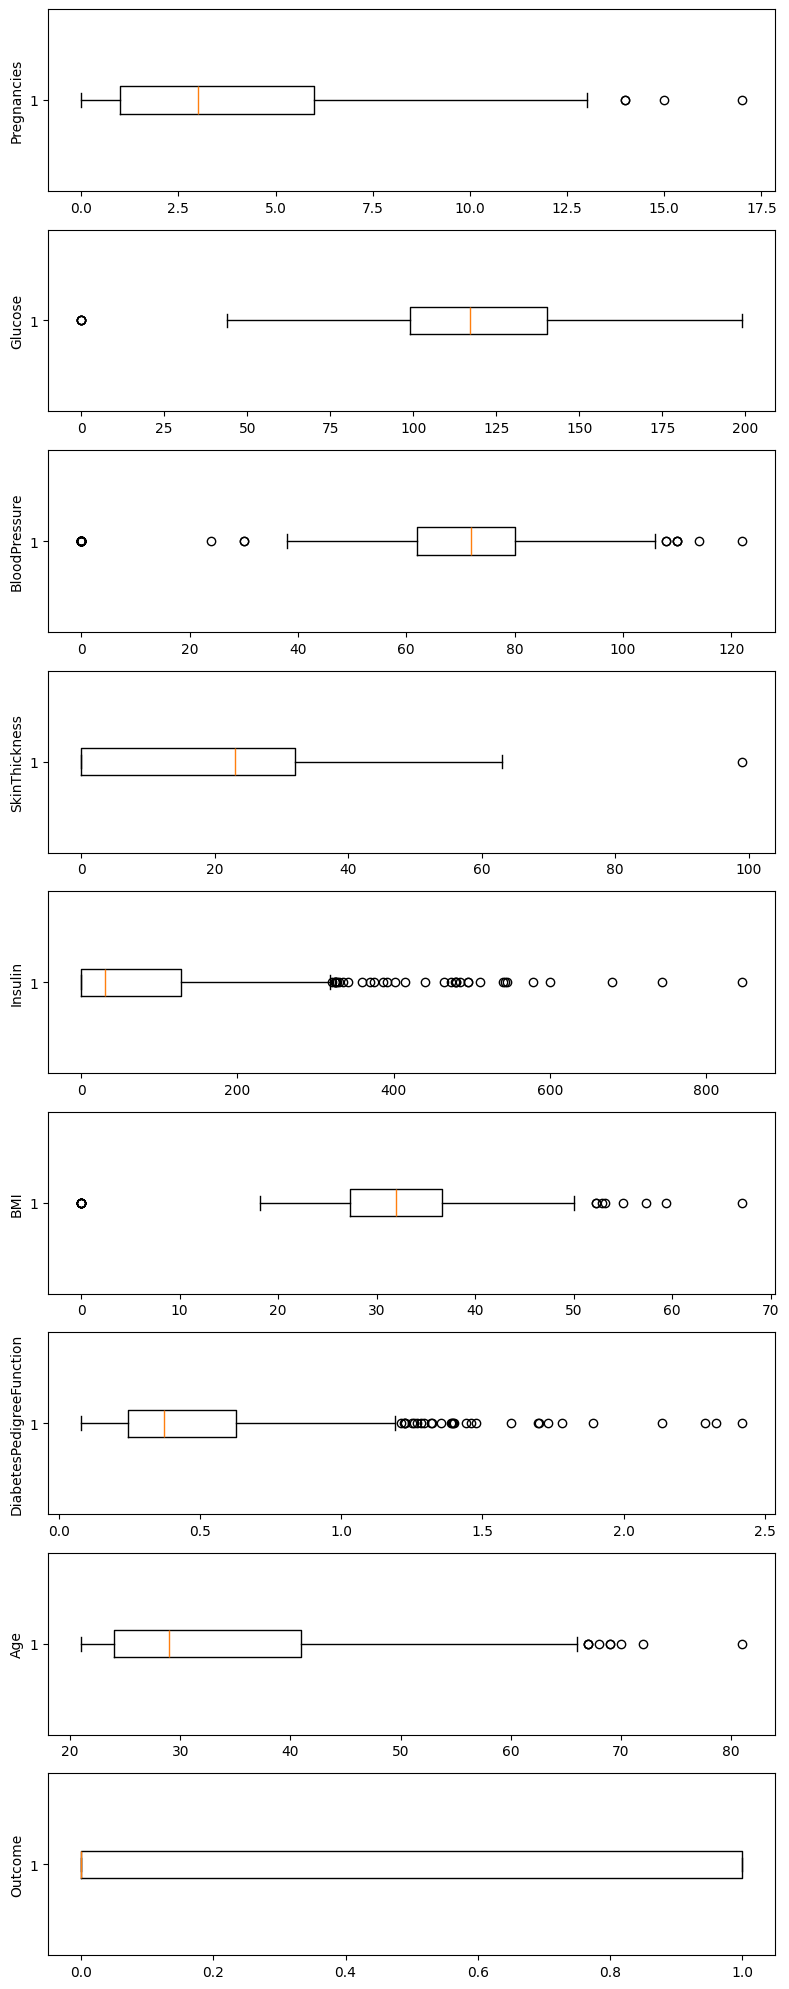

In [4]:
# dpi stands for dots per inch, which controls the resolution of the plot.
fig, axs = plt.subplots(len(df.columns), 1, figsize=(8, 20), dpi=100) 

# i is the index of the current column in the loop
# column is the name of the current column
# enumerate(df.columns) returns pairs of (index, column_name)
for i, column in enumerate(df.columns):
    axs[i].boxplot(df[column], vert=False)
    axs[i].set_ylabel(column)

plt.tight_layout()  # Adjusts subplot params for a nicer fit
plt.show()

## <br>Step 4: Remove Outliers Using the Interquartile Range (IQR) Method

Outlier removal helps eliminate extreme values that may negatively affect analysis and model performance.

### **What is IQR?**
- **IQR (Interquartile Range)** = Q3 (75th percentile) − Q1 (25th percentile)  
- It measures the spread of the **middle 50%** of the data.

### **Outlier Rule**
A value is considered an outlier if it is:

- **Below:** Q1 − 1.5 × IQR  
- **Above:** Q3 + 1.5 × IQR  

### **How to Apply It**
1. Compute **Q1** and **Q3** for the selected numerical column(s).  
2. Calculate the **IQR = Q3 − Q1**.  
3. Determine **lower_bound = Q1 − 1.5 × IQR** and **upper_bound = Q3 + 1.5 × IQR**.  
4. Filter the dataset to keep only values **within the bounds**.

This method is particularly useful when the data contains skewed distributions.


Q1: 0.0, Q3: 127.25


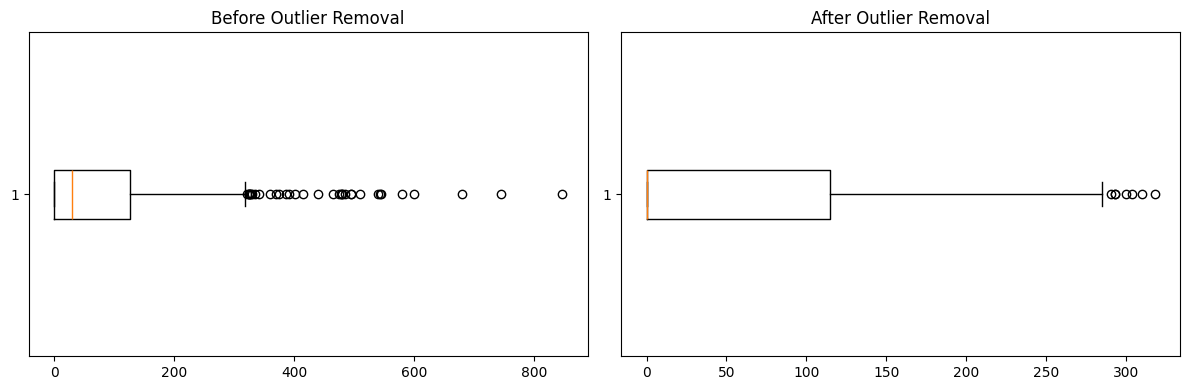

In [5]:
# np.percentile computes the q-th percentile of the data along the specified axis.
q1, q3 = np.percentile(df["Insulin"], [25, 75])
print(f"Q1: {q1}, Q3: {q3}")

iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

cleaned_df = df[df["Insulin"].between(lower_bound, upper_bound)]

fig, axs = plt.subplots(1, 2, figsize=(12, 4), dpi=100)
axs[0].boxplot(df["Insulin"], vert=False)
axs[0].set_title("Before Outlier Removal")
axs[1].boxplot(cleaned_df["Insulin"], vert=False)
axs[1].set_title("After Outlier Removal")

plt.tight_layout()
plt.show()


## <br>Step 5: Correlation Analysis

Correlation analysis helps you understand how features relate to each other and to the target variable (**Outcome**).  
It is useful for detecting important features, multicollinearity, and overall data patterns.

### **Key Steps**

- **`df.corr()`**  
  Computes pairwise correlation coefficients between all numerical columns.

- **Correlation Heatmap (using Seaborn)**  
  A heatmap visually represents the correlation matrix, making strong positive or negative correlations easy to spot.

- **Sort Correlation Values**  
  Using `df.corr()['Outcome'].sort_values()` allows you to identify which features are most positively or negatively correlated with the target.

### **Why It Matters**
Correlation helps guide feature selection and provides early insight into which variables might influence predictions.


(9, 9)
               Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin  \
Pregnancies       1.000000  0.129459       0.141282      -0.081672 -0.073535   
Glucose           0.129459  1.000000       0.152590       0.057328  0.331357   
BloodPressure     0.141282  0.152590       1.000000       0.207371  0.088933   
SkinThickness    -0.081672  0.057328       0.207371       1.000000  0.436783   
Insulin          -0.073535  0.331357       0.088933       0.436783  1.000000   

                    BMI  DiabetesPedigreeFunction       Age   Outcome  
Pregnancies    0.017683                 -0.033523  0.544341  0.221898  
Glucose        0.221071                  0.137337  0.263514  0.466581  
BloodPressure  0.281805                  0.041265  0.239528  0.065068  
SkinThickness  0.392573                  0.183928 -0.113970  0.074752  
Insulin        0.197859                  0.185071 -0.042163  0.130548  


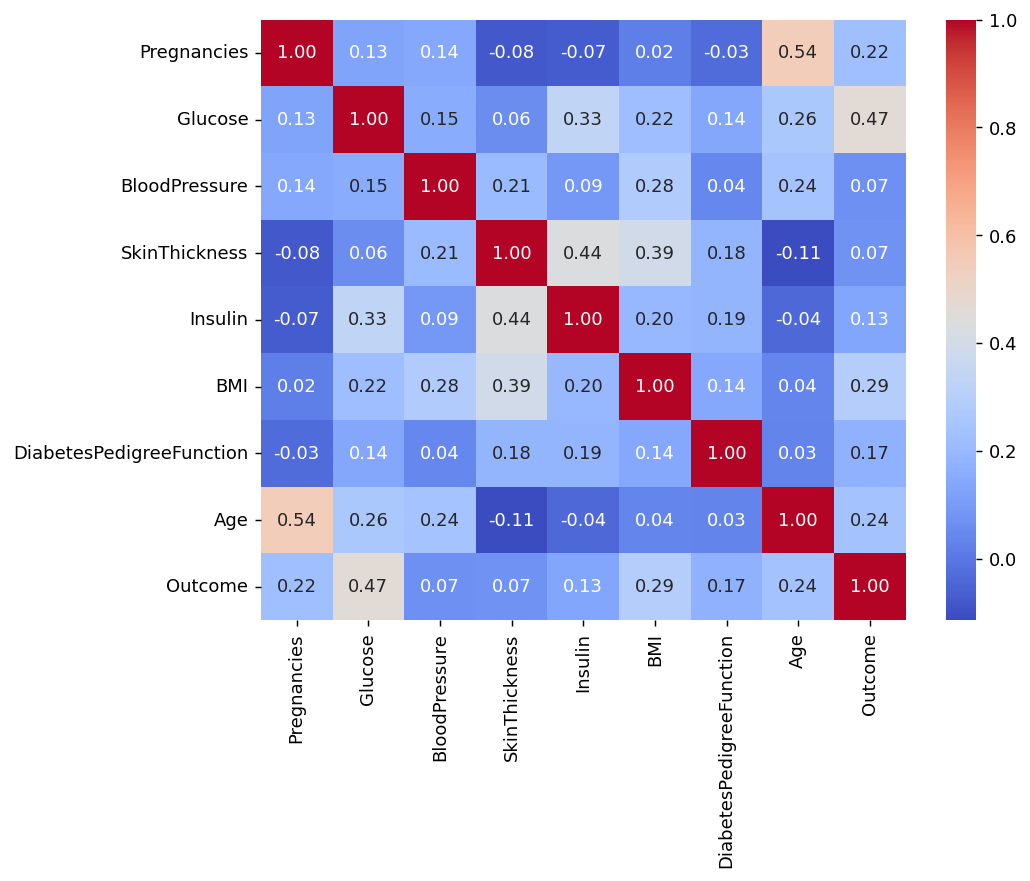

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [6]:
corr = df.corr()

print(corr.shape)
print(corr.head())

plt.figure(dpi=130, figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

print(corr["Outcome"].sort_values(ascending=False))

## <br>Step 6: Visualize Target Variable Distribution

Check if target classes (Diabetes vs Not Diabetes) are balanced, affecting model training and evaluation.

- **plt.pie()**: Pie chart to display proportion of each class in the target variable 'Outcome'.




Outcome
0    500
1    268
Name: count, dtype: int64


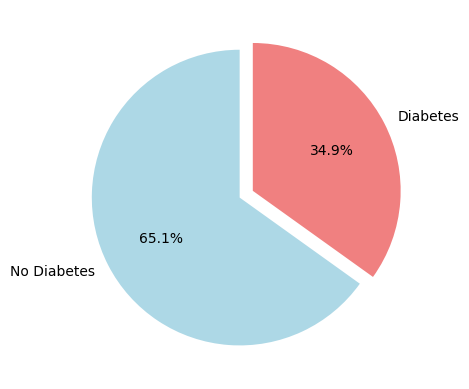

In [7]:
print(df["Outcome"].value_counts())

plt.pie(
    df["Outcome"].value_counts(), 
    labels=['No Diabetes', 'Diabetes'], 
    autopct='%1.1f%%', # explanation: https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_features.html
    startangle=90,     # start angle of the pie chart
    explode=[0.05, 0.05], # to separate the slices a bit 
    colors=['lightblue', 'lightcoral'] # custom colors for better aesthetics
)
plt.show()

## <br>Step 7: Separate Features and Target Variable

Before training a machine learning model, you must separate the **independent variables (features)** from the **dependent variable (target)**.

### **How to Separate Them**

- **`df.drop(columns=[...])`**  
  Removes the target column (`Outcome`) from the dataset to create the feature matrix **X**.

- **`df['Outcome']`**  
  Selects only the target column to create the target vector **Y**.

### **Why This Step Is Important**
- ML models require features (**X**) and target (**Y**) as separate inputs.
- Ensures clean structure for training, testing, and evaluation.


In [8]:
X = df.drop(columns=['Outcome'])
Y = df['Outcome']

print(X.head())
print("---")
print(Y.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  
---
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64


## <br>Step 8: Feature Scaling — Normalization and Standardization

Feature scaling ensures that all numerical features operate on a similar scale, which is crucial for many machine learning algorithms that are sensitive to differences in magnitude.

---

### **1. Normalization (Min-Max Scaling)**  
Rescales features to a **0–1 range**.  
This is especially useful for algorithms such as **k-NN**, **neural networks**, and any distance-based methods.

- **Class:** `MinMaxScaler` from `sklearn`
- **Method:** `.fit_transform()`  
  Learns the minimum and maximum values from the data and scales all values into the 0–1 range.

---

### **2. Standardization (Z-score Scaling)**  
Transforms features to have:  
- **Mean = 0**  
- **Standard deviation = 1**

This is often more appropriate when features follow a **normal distribution**, and it benefits algorithms like **logistic regression**, **SVM**, and **linear models**.

- **Class:** `StandardScaler` from `sklearn`

---

### **Why Scaling Matters**
- Prevents large-scale features from dominating smaller-scale ones  
- Improves training stability  
- Often leads to better and faster model convergence


In [9]:
# 1. Normalization (Min-Max Scaling)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5].round(2))  # Display first 5 rows of scaled features
print("---")

# 2. Standardization (Z-Score Scaling)
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

print(X_standardized[0:5].round(2))  # Display first 5 rows of standardized features

[[0.35 0.74 0.59 0.35 0.   0.5  0.23 0.48]
 [0.06 0.43 0.54 0.29 0.   0.4  0.12 0.17]
 [0.47 0.92 0.52 0.   0.   0.35 0.25 0.18]
 [0.06 0.45 0.54 0.23 0.11 0.42 0.04 0.  ]
 [0.   0.69 0.33 0.35 0.2  0.64 0.94 0.2 ]]
---
[[ 0.64  0.85  0.15  0.91 -0.69  0.2   0.47  1.43]
 [-0.84 -1.12 -0.16  0.53 -0.69 -0.68 -0.37 -0.19]
 [ 1.23  1.94 -0.26 -1.29 -0.69 -1.1   0.6  -0.11]
 [-0.84 -1.   -0.16  0.15  0.12 -0.49 -0.92 -1.04]
 [-1.14  0.5  -1.5   0.91  0.77  1.41  5.48 -0.02]]


### Advantages of Data Preprocessing

- **Improves Data Quality:** Cleans, corrects, and organizes raw data.  
- **Enhances Model Accuracy:** Removes noise and irrelevant information.  
- **Reduces Overfitting:** Handles outliers and redundant features.  
- **Speeds Up Training:** Scaled and simplified data trains faster.  
- **Ensures Algorithm Compatibility:** Converts data into ML-friendly formats.
